In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=fmax*2
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.5, fmax=fmax)
dataset = EPFLP300()

In [3]:
subject, session, run = 1, "session_1", "run_1"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
138 matching events found
No baseline correction applied


Number of events,138
Events,NonTarget: 115Target: 23
Time range,0.000 – 0.656 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


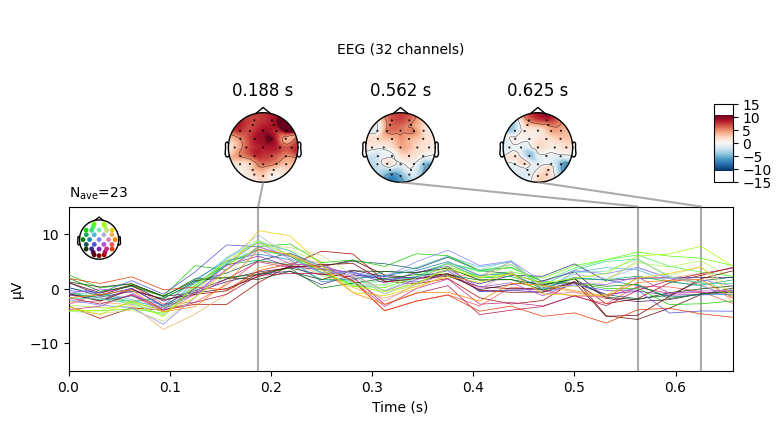

No projector specified for this dataset. Please consider the method self.add_proj.


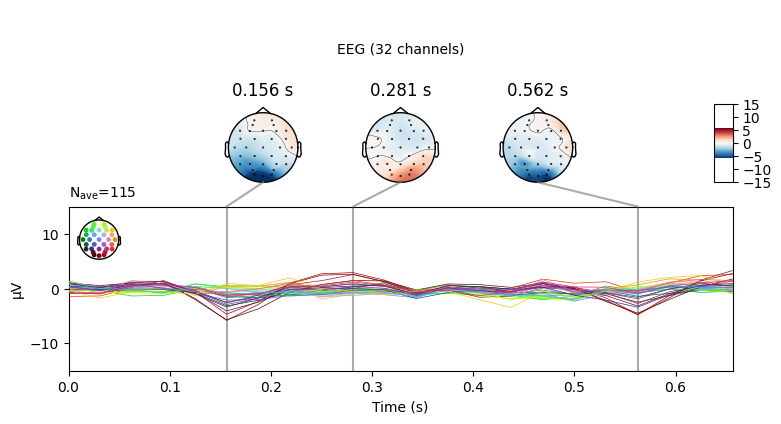

No projector specified for this dataset. Please consider the method self.add_proj.


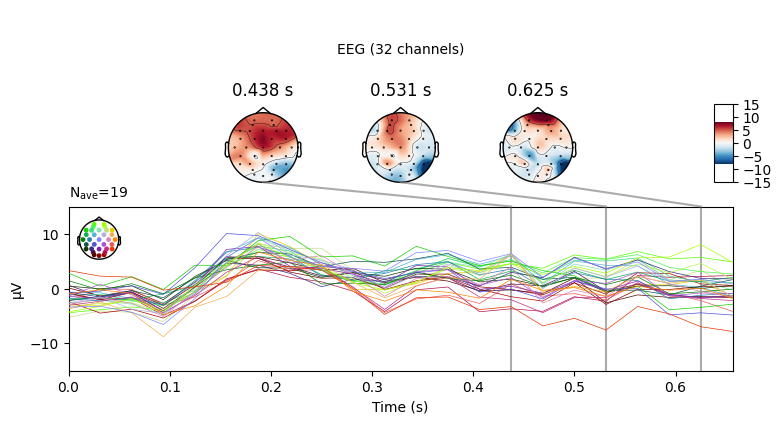

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly as tl
#try:
#    tl.set_backend('jax')
#except AttributeError:
#    tl.set_backend('jax')

In [8]:
import tensorly.decomposition
import matplotlib.pyplot as plt

X_train = epochs_train.get_data().astype(np.float32)
y_train = labels_train
X_test = epochs_test.get_data().astype(np.float32)
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

print(X_train.shape)
X_train, factors = tensorly.decomposition.partial_tucker(X_train, modes=(1,), rank=8)
factors = [factors[0],tl.eye(X_train.shape[2])]
print(X_train.shape)
X_test = tensorly.tenalg.multi_mode_dot(X_test, factors, modes=(1,), transpose=True)


#plt.semilogy(np.mean(np.abs(X_train), axis=(0,2)), label='space')
#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1)), label='time')
#plt.legend()

(69, 32, 22)
(69, 8, 22)


/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/tensorly/decomposition/_tucker.py:127: Warning: Given only one int for 'rank' instead of a list of 1 modes. Using this rank for all modes.
  warnings.warn(message, Warning)


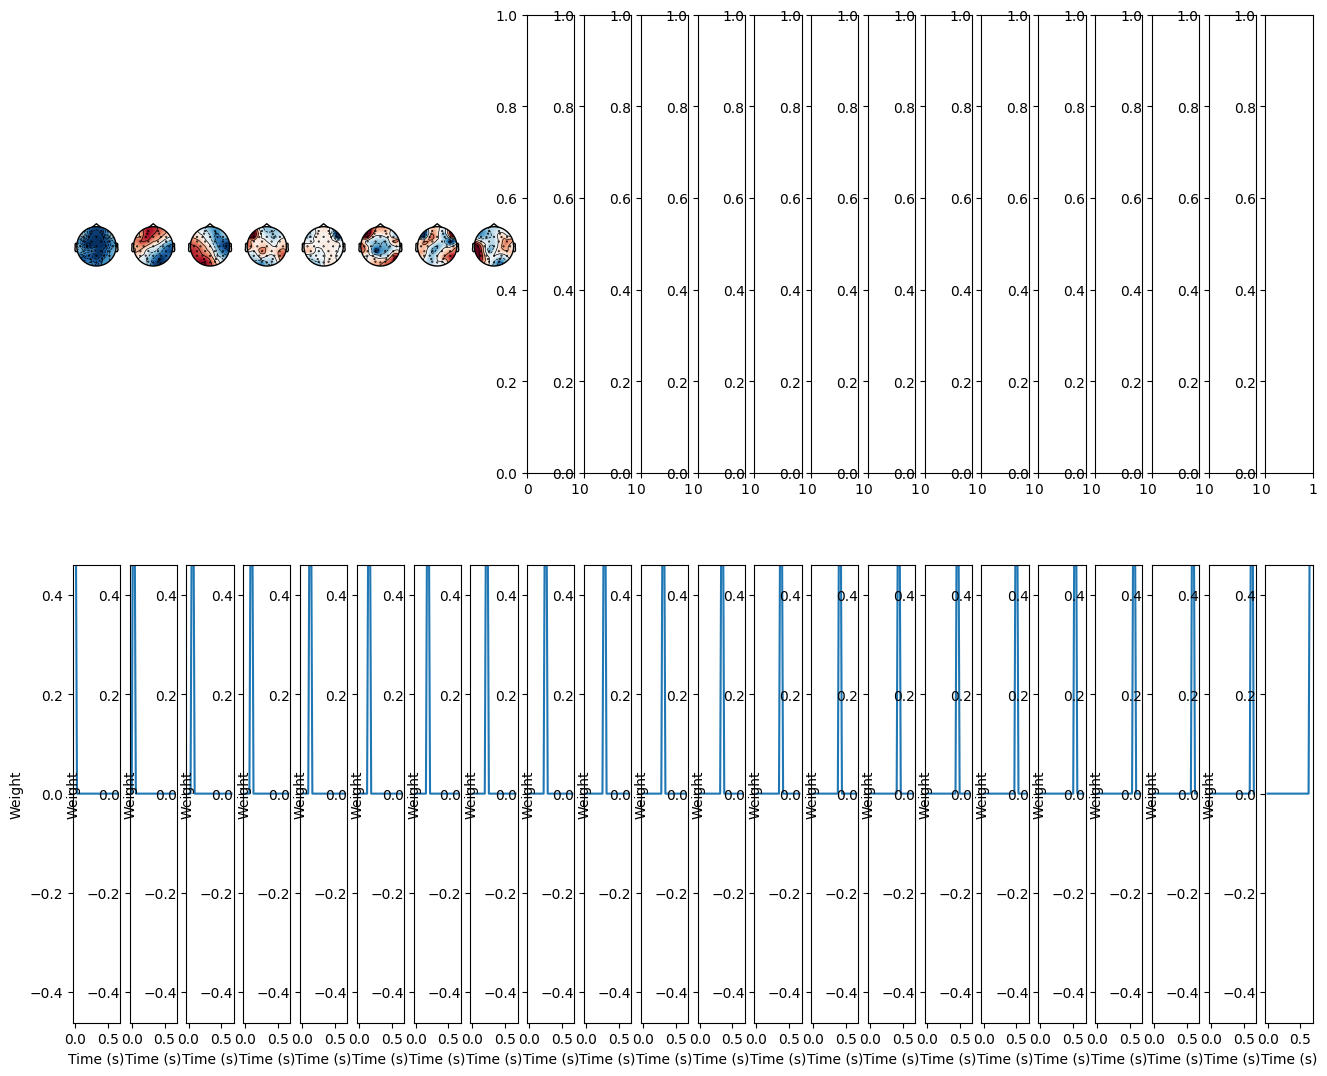

In [27]:
fig, axs = plt.subplots(2, max(X_train.shape[1:]), figsize=(16,6*2))
for i in range(X_train.shape[1]):
    w = factors[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
for i in range(X_train.shape[2]):
    w =factors[1][:,i]
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])


In [9]:
hoda = HODA(max_iter=128, rank=4, tol=1e-6,
            initialize ='svd', verbose=True,
            shrinkage='oas', toeplitz=(1,))
#%lprun -f  hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0779  shrinkage=0.2194  step=2.9478e+00
[1/128]  shrinkage=0.0897  shrinkage=0.1667  step=2.6036e+00
[2/128]  shrinkage=0.0810  shrinkage=0.2269  step=2.1613e+00
[3/128]  shrinkage=0.0898  shrinkage=0.1979  step=1.6184e+00
[4/128]  shrinkage=0.0894  shrinkage=0.2333  step=1.5772e+00
[5/128]  shrinkage=0.0902  shrinkage=0.2180  step=1.6023e+00
[6/128]  shrinkage=0.0909  shrinkage=0.2362  step=1.5789e+00
[7/128]  shrinkage=0.0907  shrinkage=0.2243  step=1.6145e+00
[8/128]  shrinkage=0.0915  shrinkage=0.2369  step=1.5496e+00
[9/128]  shrinkage=0.0910  shrinkage=0.2264  step=1.5831e+00
[10/128]  shrinkage=0.0918  shrinkage=0.2362  step=1.4688e+00
[11/128]  shrinkage=0.0912  shrinkage=0.2272  step=1.5337e+00
[12/128]  shrinkage=0.0920  shrinkage=0.2348  step=7.1129e-01
[13/128]  shrinkage=0.0914  shrinkage=0.2275  step=6.2541e-01
[14/128]  shrinkage=0.0921  shrinkage=0.2331  step=5.0287e-01
[15/128]  shrinkage=0.0915  shrinkage=0.2276  step=4.2241e-01
[16/128]  shrinkag

/data/Workspace/PhD/hoda-bci/hoda.py:104: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.array(self.projs_)[perm],


shrinkage=0.0922  shrinkage=0.2278  step=1.5561e-02
[30/128]  shrinkage=0.0922  shrinkage=0.2279  step=1.2691e-02
[31/128]  shrinkage=0.0922  shrinkage=0.2278  step=9.5383e-03
[32/128]  shrinkage=0.0923  shrinkage=0.2279  step=7.7802e-03
[33/128]  shrinkage=0.0922  shrinkage=0.2278  step=5.8390e-03
[34/128]  shrinkage=0.0923  shrinkage=0.2278  step=4.7626e-03
[35/128]  shrinkage=0.0922  shrinkage=0.2278  step=3.5707e-03
[36/128]  shrinkage=0.0923  shrinkage=0.2278  step=2.9122e-03
[37/128]  shrinkage=0.0922  shrinkage=0.2278  step=2.1819e-03
[38/128]  shrinkage=0.0923  shrinkage=0.2278  step=1.7793e-03
[39/128]  shrinkage=0.0922  shrinkage=0.2278  step=1.3323e-03
[40/128]  shrinkage=0.0923  shrinkage=0.2278  step=1.0864e-03
[41/128]  shrinkage=0.0922  shrinkage=0.2278  step=8.1316e-04
[42/128]  shrinkage=0.0923  shrinkage=0.2278  step=6.6296e-04
[43/128]  shrinkage=0.0922  shrinkage=0.2278  step=4.9608e-04
[44/128]  shrinkage=0.0923  shrinkage=0.2278  step=4.0440e-04
[45/128]  shrinkag

HODA(initialize='svd', max_iter=128, rank=4, toeplitz=(1,), tol=1e-06,
     verbose=True)

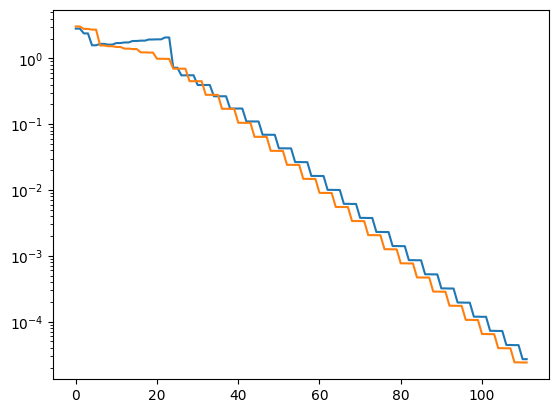

In [10]:
plt.semilogy(hoda.updates_[:,:hoda.iter_])
plt.show()

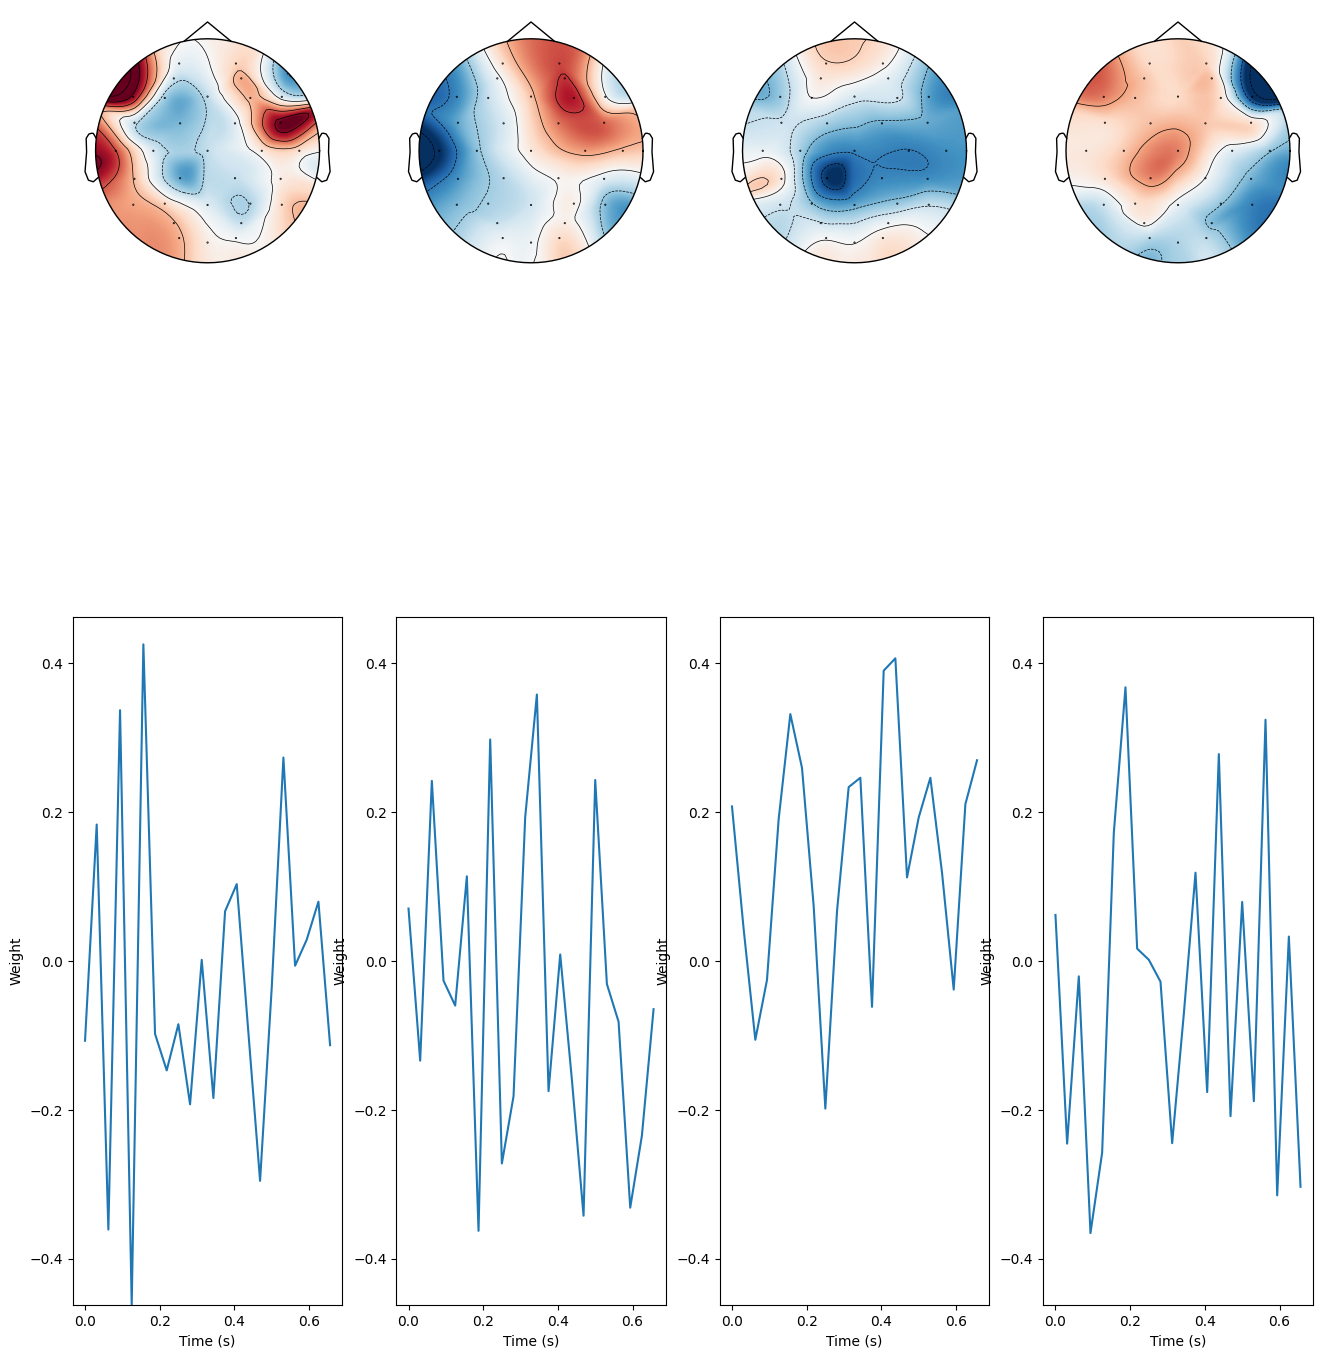

In [11]:

fig, axs = plt.subplots(2,hoda.rank, figsize=(16,6*3))
projs = [factors[k] @ p for k, p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank):
    w = projs[1][:,i]
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])


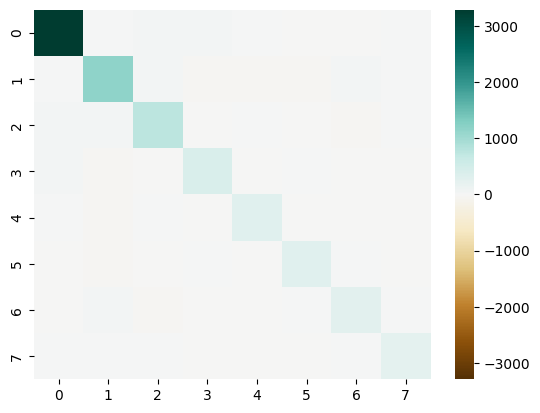

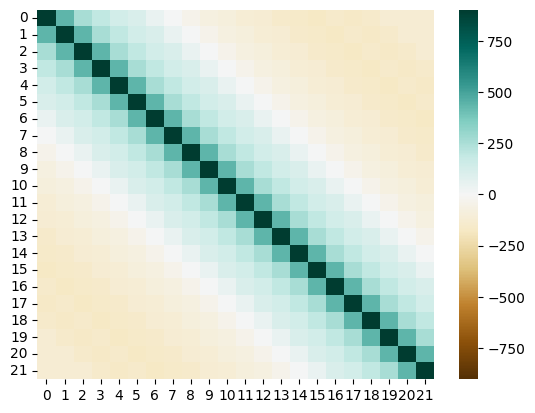

In [12]:
for k in range(2):
    cov = hoda.scatter_w_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

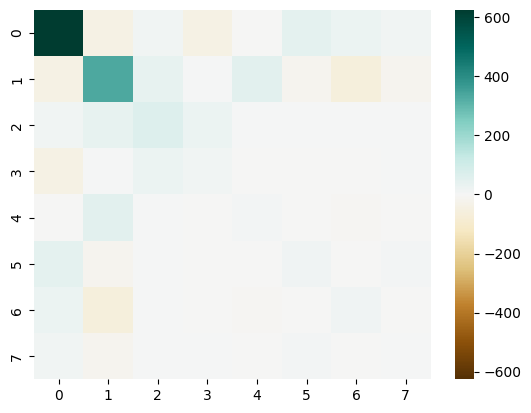

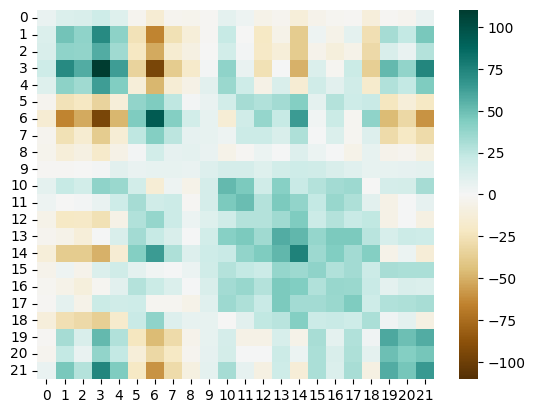

In [13]:
for k in range(2):
    cov = hoda.scatter_b_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

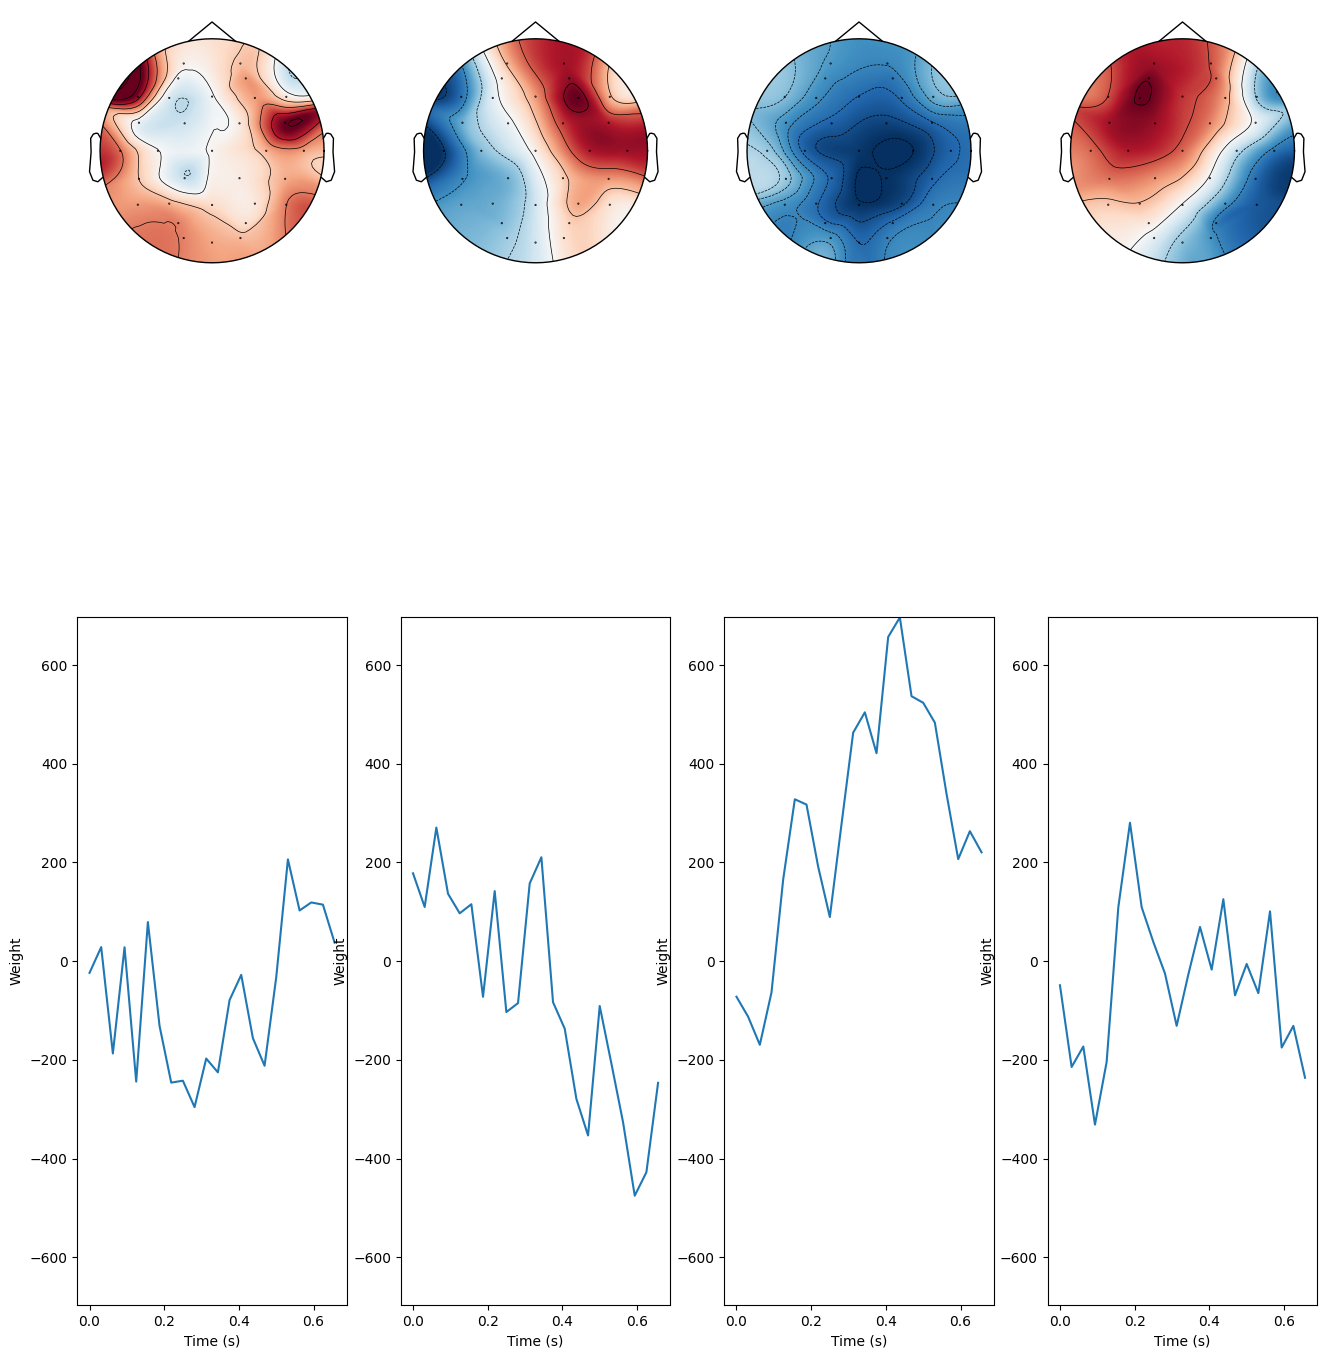

In [14]:
fig, axs = plt.subplots(2,hoda.rank, figsize=(16,6*3))
aps = [factors[k] @ hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank):
    w = aps[1][:,i]
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])

In [15]:
Xt_train = hoda.transform(X_train)
Xt_test = hoda.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

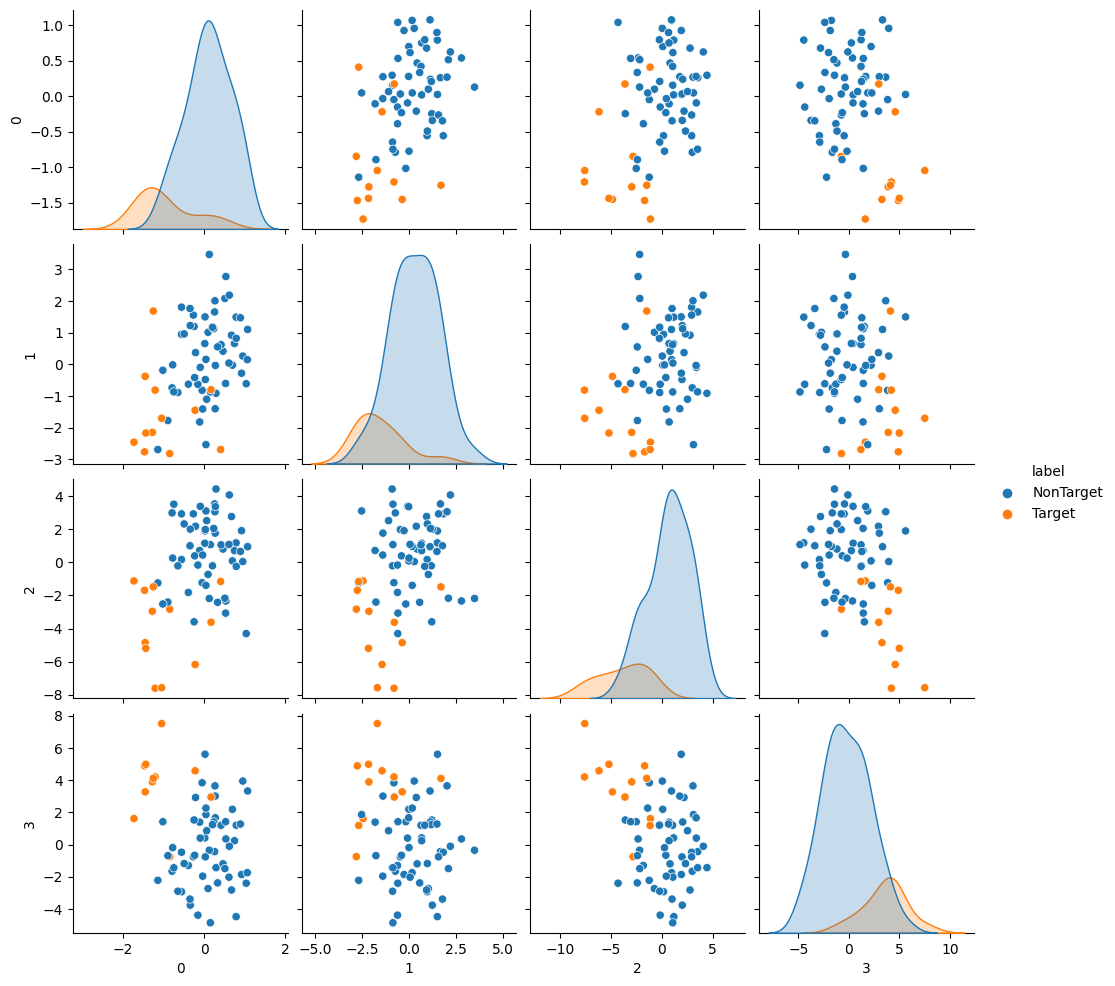

In [17]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [18]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.9897660818713451

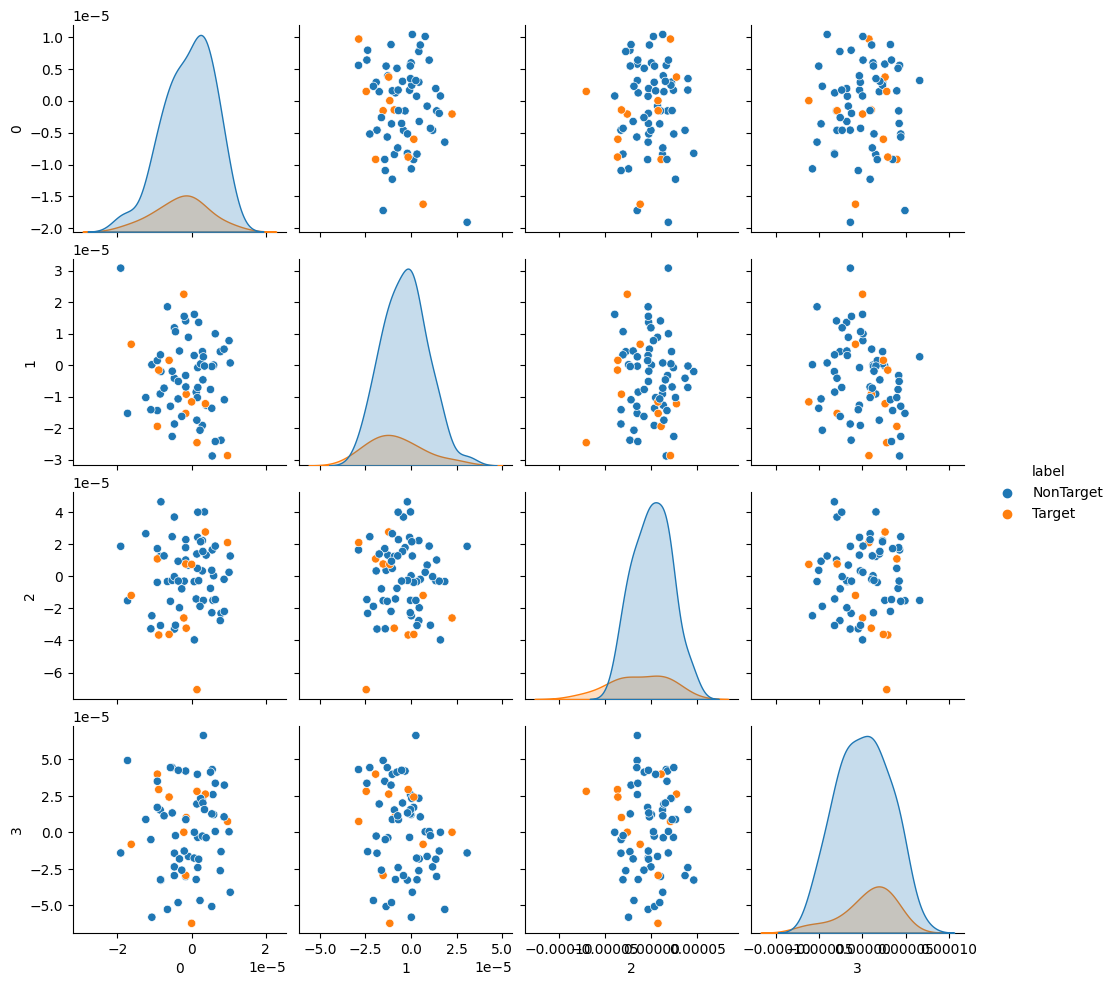

In [19]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [20]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.6394984326018809